In [22]:
# Install and import necessary libraries
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
# For models
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import shap

# Download VADER lexicon if not already present
nltk.download('vader_lexicon', quiet=True)

True

In [23]:
asr = pd.read_csv(r"..\AirlineScrappedReview_Processed_StandardizedRoutes.csv")

In [24]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2807 entries, 0 to 2806
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Passanger_Name      2807 non-null   object 
 1   Route               2807 non-null   object 
 2   Rating              2807 non-null   float64
 3   Verified            2807 non-null   object 
 4   Review_title        2807 non-null   object 
 5   Review_content      2807 non-null   object 
 6   Traveller_Type      2807 non-null   object 
 7   Class               2807 non-null   object 
 8   Start_Location      2807 non-null   object 
 9   End_Location        2807 non-null   object 
 10  Layover_Route       484 non-null    object 
 11  Start_Latitude      2747 non-null   float64
 12  Start_Longitude     2747 non-null   float64
 13  Start_Address       2807 non-null   object 
 14  End_Latitude        2708 non-null   float64
 15  End_Longitude       2708 non-null   float64
 16  End_Ad

<h1>Data Cleaning</h1>

In [25]:
asr = asr[asr['Class'] != "Unknown"].reset_index(drop=True)
asr = asr[asr['Traveller_Type'] != "Unknown"].reset_index(drop=True)
asr = asr[asr['Traveller_Type'] != "Various"].reset_index(drop=True)

<h1>One Hot Encoding</h1>

In [26]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(asr[['Class', 'Traveller_Type', 'Verified']])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['Class', 'Traveller_Type', 'Verified']))

asr = pd.concat([asr.drop(['Class', 'Traveller_Type', 'Verified'], axis=1), one_hot_df], axis=1)
asr = asr.drop(['Start_Latitude', 'Start_Longitude', 'End_Latitude', 'End_Longitude', 'Verified_Not Verified', 'Route_Frequency'], axis=1)

In [27]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2803 entries, 0 to 2802
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Passanger_Name                 2803 non-null   object 
 1   Route                          2803 non-null   object 
 2   Rating                         2803 non-null   float64
 3   Review_title                   2803 non-null   object 
 4   Review_content                 2803 non-null   object 
 5   Start_Location                 2803 non-null   object 
 6   End_Location                   2803 non-null   object 
 7   Layover_Route                  483 non-null    object 
 8   Start_Address                  2803 non-null   object 
 9   End_Address                    2803 non-null   object 
 10  Sentiment_Score                2803 non-null   float64
 11  Satisfaction                   2803 non-null   int64  
 12  Has_Layover                    2803 non-null   i

## Step 3: Feature Selection and Preparation

### Selected Features:
1. **Traveller_Type**: Type of passenger (Business, Leisure, etc.)
2. **Class**: Flight class (Economy, Business, First Class)
3. **Verified**: Whether the review is verified
4. **Sentiment_Score**: Calculated sentiment from review text (VADER compound score)
5. **Has_Layover**: Whether the flight had a layover (engineered feature)
6. **Route_Frequency**: Frequency encoding of standardized routes (how popular is this route)

### Why these features?
- **Traveller-related**: Type and Class directly indicate passenger segment
- **Flight-related**: Route popularity (frequency) and layover information capture route characteristics
- **Review-related**: Verified status and sentiment provide review quality indicators

### Route Feature Engineering:
- **Standardization**: Converted all "City1 to City2" formats to "City1-City2" for consistency
- **Frequency Encoding**: Popular routes get higher values, which may correlate with satisfaction
  - More frequent routes → Better established service
  - Less frequent routes → Potentially more issues or newer service


In [28]:
label_encoder = LabelEncoder()
asr['Route_Standardized'] = label_encoder.fit_transform(asr['Route_Standardized'])

In [29]:
# Select features for modeling (using Route_Frequency instead of raw Route)
feature_columns = [
    'Traveller_Type_Business', 'Traveller_Type_Family Leisure', 'Traveller_Type_Couple Leisure',  'Traveller_Type_Solo Leisure','Class_Business Class', 'Class_Economy Class', 'Class_First Class', 'Class_Premium Economy', 'Verified_Trip Verified', 'Sentiment_Score', 'Has_Layover'
]
X = asr[feature_columns]
y = asr['Satisfaction']
print(f"\nSelected features summary:")
print(asr[feature_columns].describe())


Selected features summary:
       Traveller_Type_Business  Traveller_Type_Family Leisure  \
count              2803.000000                    2803.000000   
mean                  0.221905                       0.134499   
std                   0.415602                       0.341248   
min                   0.000000                       0.000000   
25%                   0.000000                       0.000000   
50%                   0.000000                       0.000000   
75%                   0.000000                       0.000000   
max                   1.000000                       1.000000   

       Traveller_Type_Couple Leisure  Traveller_Type_Solo Leisure  \
count                    2803.000000                  2803.000000   
mean                        0.337139                     0.306457   
std                         0.472817                     0.461104   
min                         0.000000                     0.000000   
25%                         0.000000     

In [30]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

Training set size: 2242
Test set size: 561

Training set target distribution:
Satisfaction
0    1269
1     973
Name: count, dtype: int64

Test set target distribution:
Satisfaction
0    317
1    244
Name: count, dtype: int64


### Model 1: Random Forest Classifier

In [31]:
# Train Random Forest Classifier
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Training completed!")

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("\n" + "="*60)
print("RANDOM FOREST CLASSIFIER - RESULTS")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Dissatisfied', 'Satisfied']))

Training Random Forest Classifier...
Training completed!

RANDOM FOREST CLASSIFIER - RESULTS

Accuracy:  0.8146
Precision: 0.7823
Recall:    0.7951
F1-Score:  0.7886

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.84      0.83      0.83       317
   Satisfied       0.78      0.80      0.79       244

    accuracy                           0.81       561
   macro avg       0.81      0.81      0.81       561
weighted avg       0.82      0.81      0.81       561



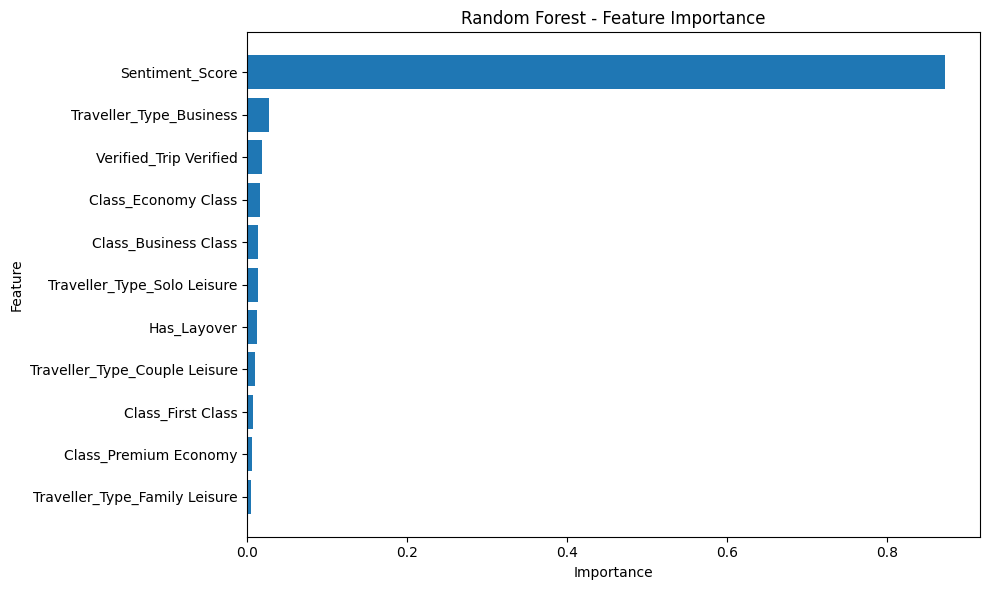


Feature Importance Rankings:
                          feature  importance
9                 Sentiment_Score    0.872912
0         Traveller_Type_Business    0.027567
8          Verified_Trip Verified    0.018250
5             Class_Economy Class    0.016033
4            Class_Business Class    0.013030
3     Traveller_Type_Solo Leisure    0.012962
10                    Has_Layover    0.012646
2   Traveller_Type_Couple Leisure    0.009396
6               Class_First Class    0.006693
7           Class_Premium Economy    0.005745
1   Traveller_Type_Family Leisure    0.004766


In [32]:
# Feature importance visualization
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest - Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nFeature Importance Rankings:")
print(feature_importance)

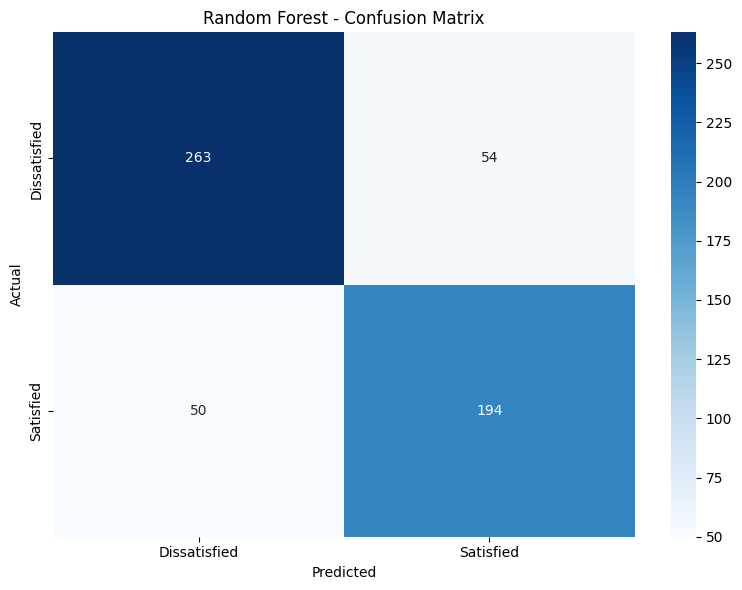

In [33]:
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
plt.show()


SHAP GLOBAL FEATURE IMPORTANCE - ALL FEATURES


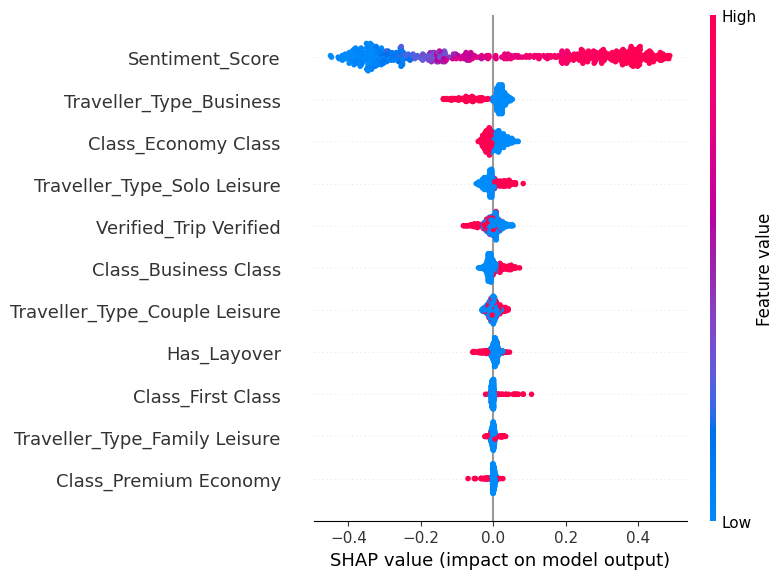

In [34]:
# SHAP Global Explainer - All Features
print("\n" + "="*70)
print("SHAP GLOBAL FEATURE IMPORTANCE - ALL FEATURES")
print("="*70)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values[:, :, 1],  # All samples, all features, Satisfied class
    X_test,
    feature_names=feature_columns
)


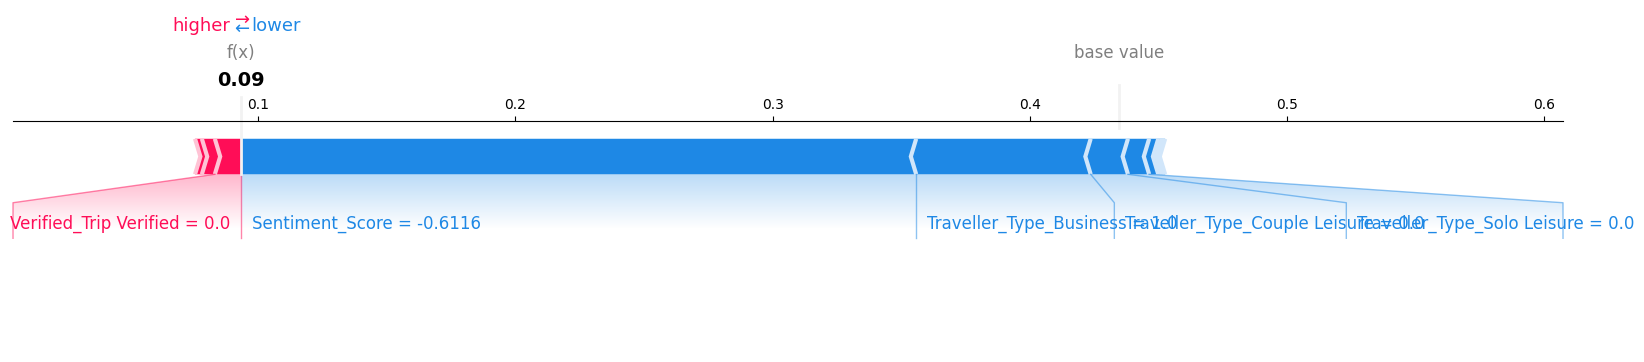

In [35]:
# LOCAL SHAP

i=0
shap_explanation = shap.Explanation(
    values=shap_values[i, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[i].values,
    feature_names=feature_columns
)

fig = shap.plots.force(shap_explanation,matplotlib=True, show=False)
plt.show()

### Model 2: Shallow Feed-Forward Neural Network (FFNN)

In [36]:
# Scale features for neural network (important for gradient-based optimization)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("Features scaled for neural network training")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}")

Features scaled for neural network training
Training data shape: (2242, 11)
Test data shape: (561, 11)


In [37]:
# Build Shallow FFNN model
print("Building Shallow Feed-Forward Neural Network...")

ffnn_model = keras.Sequential([
    # Input layer
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    # First hidden layer with 64 neurons
    layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.3),
    
    # Second hidden layer with 32 neurons
    layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    layers.Dropout(0.2),
    
    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
ffnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("\nModel Architecture:")
ffnn_model.summary()

Building Shallow Feed-Forward Neural Network...

Model Architecture:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 64)                768       
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2,881
Trainable params: 2,881
Non-trainable params: 0
_________________________________________________

In [38]:
# Train the FFNN model
print("Training Shallow FFNN...")
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = ffnn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed!")

Training Shallow FFNN...
Epoch 1/100
57/57 [==============================] - 2s 12ms/step - loss: 0.6854 - accuracy: 0.6458 - precision_1: 0.5889 - recall_1: 0.5447 - val_loss: 0.5921 - val_accuracy: 0.7416 - val_precision_1: 0.7975 - val_recall_1: 0.6103
Epoch 2/100
57/57 [==============================] - 0s 8ms/step - loss: 0.5775 - accuracy: 0.7658 - precision_1: 0.7214 - recall_1: 0.7289 - val_loss: 0.5196 - val_accuracy: 0.7973 - val_precision_1: 0.7990 - val_recall_1: 0.7653
Epoch 3/100
57/57 [==============================] - 0s 7ms/step - loss: 0.5500 - accuracy: 0.7691 - precision_1: 0.7184 - recall_1: 0.7487 - val_loss: 0.5014 - val_accuracy: 0.8085 - val_precision_1: 0.7900 - val_recall_1: 0.8122
Epoch 4/100
57/57 [==============================] - 0s 5ms/step - loss: 0.5390 - accuracy: 0.7819 - precision_1: 0.7204 - recall_1: 0.7934 - val_loss: 0.5056 - val_accuracy: 0.8018 - val_precision_1: 0.7952 - val_recall_1: 0.7840
Epoch 5/100
57/57 [==============================]

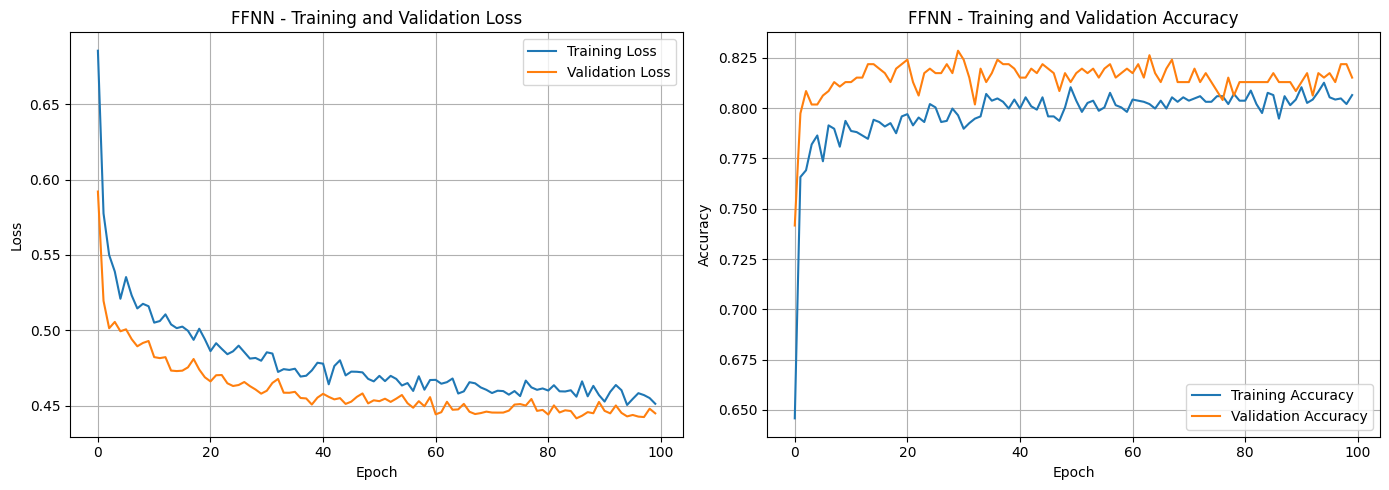

In [39]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('FFNN - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('FFNN - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [40]:
# Evaluate FFNN on test set
y_pred_ffnn_probs = ffnn_model.predict(X_test_scaled)
y_pred_ffnn = (y_pred_ffnn_probs > 0.5).astype(int).flatten()

print("="*60)
print("SHALLOW FFNN - RESULTS")
print("="*60)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_ffnn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ffnn):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_ffnn):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_ffnn):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ffnn, target_names=['Dissatisfied', 'Satisfied']))

18/18 [==============================] - 0s 4ms/step
SHALLOW FFNN - RESULTS

Accuracy:  0.8253
Precision: 0.7874
Recall:    0.8197
F1-Score:  0.8032

Classification Report:
              precision    recall  f1-score   support

Dissatisfied       0.86      0.83      0.84       317
   Satisfied       0.79      0.82      0.80       244

    accuracy                           0.83       561
   macro avg       0.82      0.82      0.82       561
weighted avg       0.83      0.83      0.83       561



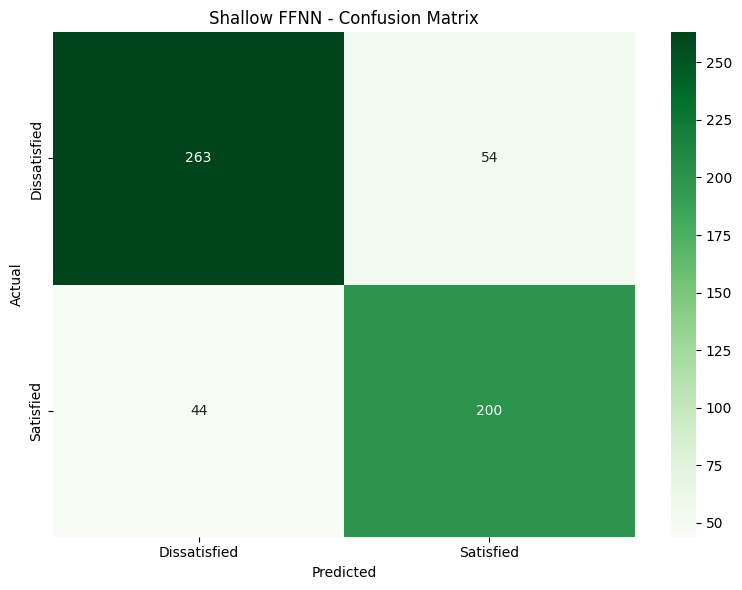

In [41]:
# Confusion Matrix for FFNN
cm_ffnn = confusion_matrix(y_test, y_pred_ffnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ffnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Shallow FFNN - Confusion Matrix')
plt.tight_layout()
plt.show()

PermutationExplainer explainer: 562it [01:40,  5.25it/s]                         
C:\Users\gchehata\AppData\Local\Temp\ipykernel_13644\872172334.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


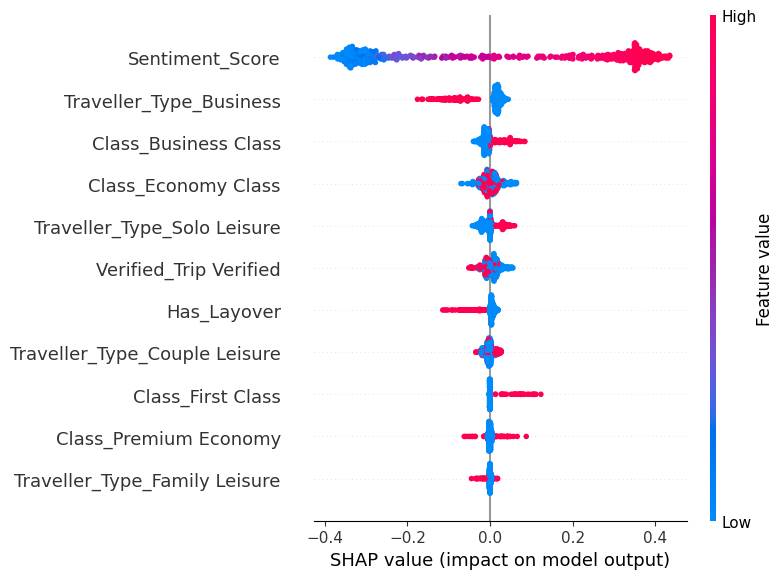

(561, 11)

In [42]:
# SHAP GLOBAL

background = shap.sample(X_train_scaled, 100, random_state=42)

explainer = shap.Explainer(ffnn_model, background.values)

shap_values = explainer(X_test_scaled.values)


shap.summary_plot(
    shap_values.values,
    X_test_scaled,
    feature_names=feature_columns
)

shap_values.shape

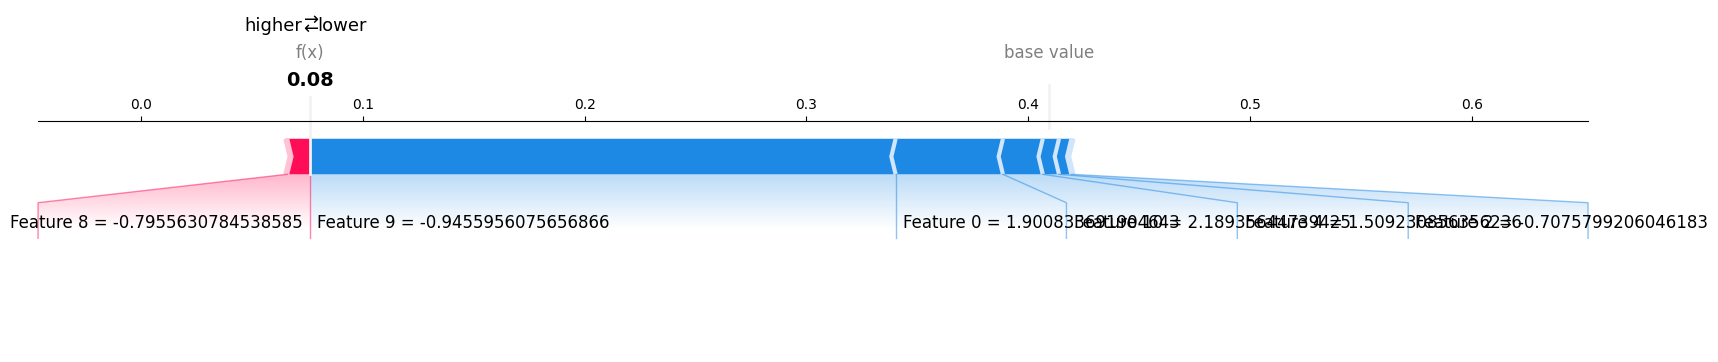

In [43]:
# LOCAL SHAP
i=0
fig = shap.plots.force(shap_values[i], matplotlib=True, show=False)


for text in fig.findobj(plt.Text):
    text.set_color('black')

ax = plt.gca()
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')


plt.show()

MODEL COMPARISON
        Model  Accuracy  Precision   Recall  F1-Score
Random Forest  0.814617   0.782258 0.795082  0.788618
 Shallow FFNN  0.825312   0.787402 0.819672  0.803213


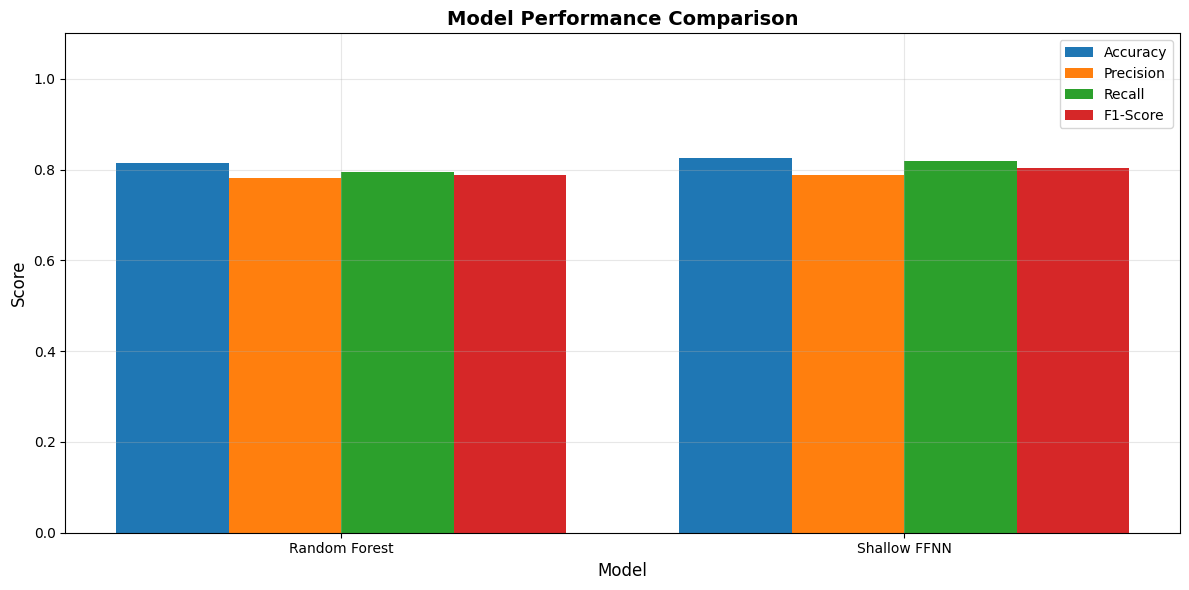

In [44]:
# Compare both models
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Shallow FFNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ffnn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_ffnn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_ffnn)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_ffnn)
    ]
})

print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df['Model']))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics):
    ax.bar(x + i*width, comparison_df[metric], width, label=metric, color=colors[i])

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Inference Function

In [ ]:
def predict_satisfaction(input_df, model, scaler, encoder, label_encoder, sia):
    """
    Predict satisfaction for new passenger data using the Neural Network model.
    Applies all preprocessing steps from the training pipeline.
    
    Parameters:
    -----------
    input_df : pd.DataFrame
        DataFrame with one row containing raw unprocessed data
        Required columns: ['Review_content', 'Class', 
                          'Traveller_Type', 'Verified', 'Has_Layover']
    model : keras.Model
        Trained FFNN model
    scaler : StandardScaler
        Fitted scaler used during training
    encoder : OneHotEncoder
        Fitted one-hot encoder for categorical features
    sia : SentimentIntensityAnalyzer
        VADER sentiment analyzer
        
    Returns:
    --------
    dict: Prediction results with probability and class
    """
    # Create a copy to avoid modifying original
    df = input_df.copy()
    
    # Step 1: Calculate sentiment score from review content
    if 'Review_content' in df.columns:
        df['Sentiment_Score'] = df['Review_content'].apply(
            lambda x: sia.polarity_scores(str(x))['compound'] if pd.notna(x) else 0
        )
    else:
        df['Sentiment_Score'] = 0
    
    # Step 2: Clean categorical features (remove Unknown/Various if present)
    if 'Class' in df.columns:
        if df['Class'].iloc[0] in ['Unknown']:
            raise ValueError("Class cannot be 'Unknown'")
    
    if 'Traveller_Type' in df.columns:
        if df['Traveller_Type'].iloc[0] in ['Unknown', 'Various']:
            raise ValueError("Traveller_Type cannot be 'Unknown' or 'Various'")
    
    # Step 3: One-hot encode categorical features
    categorical_cols = ['Class', 'Traveller_Type', 'Verified']
    one_hot_encoded = encoder.transform(df[categorical_cols])
    one_hot_df = pd.DataFrame(
        one_hot_encoded, 
        columns=encoder.get_feature_names_out(categorical_cols),
        index=df.index
    )
    
    
    # Step 4: Combine features in correct order
    feature_columns = [
        'Traveller_Type_Business', 'Traveller_Type_Family Leisure', 
        'Traveller_Type_Couple Leisure', 'Traveller_Type_Solo Leisure',
        'Class_Business Class', 'Class_Economy Class', 
        'Class_First Class', 'Class_Premium Economy',
        'Verified_Trip Verified',
        'Sentiment_Score', 'Has_Layover'
    ]
    
    # Create final feature dataframe
    final_df = pd.DataFrame(index=df.index)
    
    # Add one-hot encoded columns
    for col in one_hot_df.columns:
        final_df[col] = one_hot_df[col]
    
    # Add numerical columns
    final_df['Sentiment_Score'] = df['Sentiment_Score']
    final_df['Has_Layover'] = df['Has_Layover']
    
    # Ensure all feature columns exist in correct order
    final_df = final_df[feature_columns]
    
    # Step 6: Scale features
    input_scaled = scaler.transform(final_df)
    
    # Step 7: Make prediction
    probability = model.predict(input_scaled, verbose=0)[0][0]
    prediction = 1 if probability > 0.5 else 0
    
    return {
        'prediction': 'Customer will be Satisfied, Enjoy your travels!' if prediction == 1 else 'Customer will be Dissatisfied,  Need to Address their concerns!!',
        'probability': float(probability),
        'confidence': float(max(probability, 1 - probability))
    }


# Example usage
print("="*70)
print("NEURAL NETWORK INFERENCE FUNCTION")
print("="*70)

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Test with raw unprocessed sample data
sample_1 = pd.DataFrame([{
    'Review_content': 'Excellent service, very comfortable flight and friendly staff. Highly recommend!',
    'Class': 'Business Class',
    'Traveller_Type': 'Business',
    'Verified': 'Trip Verified',
    'Has_Layover': 0
}])

result_1 = predict_satisfaction(
    input_df=sample_1,
    model=ffnn_model,
    scaler=scaler,
    encoder=encoder,
    label_encoder=label_encoder,
    sia=sia
)

print("\nSample 1 - Positive Review:")
print(f"Review: '{sample_1['Review_content'].iloc[0][:60]}...'")
print(f"Class: {sample_1['Class'].iloc[0]}, Type: {sample_1['Traveller_Type'].iloc[0]}")
print(f"\n→ Prediction: {result_1['prediction']}")
print(f"  Probability: {result_1['probability']:.4f}")
print(f"  Confidence: {result_1['confidence']:.4f}")

# Test with negative review
sample_2 = pd.DataFrame([{
    'Review_content': 'amazing experience. Flight was on time, staff was nice, and seats were comfortable.',
    'Class': 'Economy Class',
    'Traveller_Type': 'Family Leisure',
    'Verified': 'Trip Verified',
    'Has_Layover': 1
}])

result_2 = predict_satisfaction(
    input_df=sample_2,
    model=ffnn_model,
    scaler=scaler,
    encoder=encoder,
    label_encoder=label_encoder,
    sia=sia
)

print("\n" + "-"*70)
print("\nSample 2 - Positive Review:")
print(f"Review: '{sample_2['Review_content'].iloc[0][:60]}...'")
print(f"Class: {sample_2['Class'].iloc[0]}, Type: {sample_2['Traveller_Type'].iloc[0]}")
print(f"\n→ Prediction: {result_2['prediction']}")
print(f"  Probability: {result_2['probability']:.4f}")
print(f"  Confidence: {result_2['confidence']:.4f}")

# Test with neutral review
sample_3 = pd.DataFrame([{
    'Review_content': 'No complaints and no problems!',
    'Class': 'Premium Economy',
    'Traveller_Type': 'Solo Leisure',
    'Verified': 'Trip Verified',
    'Has_Layover': 0
}])

result_3 = predict_satisfaction(
    input_df=sample_3,
    model=ffnn_model,
    scaler=scaler,
    encoder=encoder,
    label_encoder=label_encoder,
    sia=sia
)

print("\n" + "-"*70)
print("\nSample 3 - Neutral Review:")
print(f"Review: '{sample_3['Review_content'].iloc[0][:60]}...'")
print(f"Class: {sample_3['Class'].iloc[0]}, Type: {sample_3['Traveller_Type'].iloc[0]}")
print(f"\n→ Prediction: {result_3['prediction']}")
print(f"  Probability: {result_3['probability']:.4f}")
print(f"  Confidence: {result_3['confidence']:.4f}")

print("\n" + "="*70)

NEURAL NETWORK INFERENCE FUNCTION

Sample 1 - Positive Review:
Review: 'Excellent service, very comfortable flight and friendly staf...'
Class: Business Class, Type: Business

→ Prediction: Customer is Satisfied, Enjoy your travels!
  Probability: 0.5806
  Confidence: 0.5806

----------------------------------------------------------------------

Sample 2 - Positive Review:
Review: 'amazing experience. Flight was on time, staff was nice, and ...'
Class: Economy Class, Type: Family Leisure

→ Prediction: Customer is Satisfied, Enjoy your travels!
  Probability: 0.7712
  Confidence: 0.7712

----------------------------------------------------------------------

Sample 3 - Neutral Review:
Review: 'No complaints and no problems!...'
Class: Premium Economy, Type: Solo Leisure

→ Prediction: Customer is Dissatisfied,  Need to Address their concerns!!
  Probability: 0.1208
  Confidence: 0.8792

